In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from numpy import mean, std
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


## Load data & select features

In [2]:
# df = pd.read_csv('../feature_engineering/data_for_temporal_model.csv')
df = pd.read_csv("../../non_temporal_predictions/feature_engineering/data_with_new_features_v3.csv")
# df.rename(columns={'person': 'participant'}, inplace=True)

In [3]:
import re

def select_feature_groups(df, group_names):
    base = ['timestamp', 'participant', 'genre']

    groups = {
        "raw": ['heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm', 'iris_diameter_mm', 'pupil_iris_ratio'],
        'head_movement':['head_displacement', 'head_velocity', 'head_direction_change_rate', 'head_stability', 'centered_x', 'centered_y'],
    }

    selected = set(base)
    for name in group_names:
        selected.update(groups.get(name, []))

    return df[list(selected)]

df = select_feature_groups(df, ['raw', 'head_movement'])

## Data preprocessing

In [9]:
# Encode target variable (genre)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['genre'])
num_classes = len(label_encoder.classes_)

# Features to use
features = ['x_coordinate', 'heart_rate', 'pupil_diameter_mm', 'iris_diameter_mm',
       'centered_y', 'head_displacement', 'head_stability',
       'head_velocity', 'head_direction_change_rate',
       'pupil_iris_ratio', 'y_coordinate', 'centered_x']

# Normalize features with standardscaler
scaler = StandardScaler()
scaler.fit(df[features])

# Filter participants
train_df = df[df['participant'].isin(['kenji', 'aimen'])]
test_df = df[df['participant'] == 'clara']

# Original training features and labels
train_X_original = train_df[features]
train_y_original = train_df['label']
test_X_original = test_df[features]
test_y_original = test_df['label']


In [10]:
train_X_original

,x_coordinate,heart_rate,pupil_diameter_mm,iris_diameter_mm,centered_y,head_displacement,head_stability,head_velocity,head_direction_change_rate,pupil_iris_ratio,y_coordinate,centered_x
0,409.206897,62.000000,2.602941,11.8,-49.945073,0.000000,0.000000,0.000000,0.000000,0.220588,194.000000,59.996531
1,413.433333,61.500000,2.602941,11.8,-49.145073,4.301484,1.777114,4.301484,0.000000,0.220588,194.800000,64.222968
2,397.333333,60.000000,2.602941,11.8,-52.945073,16.542370,5.175264,5.514123,3.096881,0.220588,191.000000,48.122968
3,397.166667,60.000000,2.602941,11.8,-53.345073,0.433333,5.207589,0.216667,2.020552,0.220588,190.600000,47.956301
4,391.000000,60.000000,2.602941,11.8,-54.611739,6.295413,5.834263,2.098471,1.671507,0.220588,189.333333,41.789635
...,...,...,...,...,...,...,...,...,...,...,...,...
9339,354.483871,69.555556,2.726626,11.8,76.935619,0.965066,0.576733,0.965066,1.437645,0.231070,323.258065,-36.095340
9340,354.600000,69.666667,2.726626,11.8,77.677555,0.750969,0.747580,0.750969,1.619565,0.231070,324.000000,-35.979211
9341,355.000000,69.777778,2.726626,11.8,77.608589,0.405902,0.805218,0.405902,1.425149,0.231070,323.931034,-35.579211
9342,355.500000,69.888889,2.726626,11.8,77.577555,0.500962,0.794631,0.500962,1.405554,0.231070,323.900000,-35.079211


## Build & Train Model

In [19]:
# Create sequences with fixed window size
def create_sequences(data, labels, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(labels.iloc[i + window_size - 1])  # label at the end of the window
    return np.array(X), to_categorical(np.array(y), num_classes=num_classes)

# Fit and evaluate a model
def evaluate_model(window_size=10, epochs=15, batch_size=64, units=100, dropout_rate=0.5, dense_units=100, early_stopping_patience=10, verbose=2, learning_rate=5e-4):
    
    X_train, y_train = create_sequences(train_X_original, train_y_original, window_size)
    
    train_X, val_X, train_y, val_y = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
      
    verbose = verbose
    n_timesteps, n_features, n_outputs = train_X.shape[1], train_X.shape[2], train_y.shape[1]
    
    model = Sequential()
    model.add(Input(shape=(n_timesteps, n_features)))
    # model.add(LSTM(60, activation='relu', return_sequences=True))
    # model.add(Dropout(dropout_rate))
    
    model.add(LSTM(60, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(3, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=early_stopping_patience, restore_best_weights=True)

    # Train
    history = model.fit(train_X, train_y, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[early_stopping], validation_data=(val_X, val_y))
    
    # Evaluate
    test_X, test_y = create_sequences(test_X_original, test_y_original, window_size)
    preds = model.predict(test_X, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(test_y, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)

    #print accuracy
    accuracy = np.mean(y_true == y_pred) * 100
    print(f'Accuracy: {accuracy:.2f}%')

    return history, cm, cr, accuracy

# Summarize scores
def summarize_results(scores):
    print(scores)
    m, s = mean(scores), std(scores)
    print(f'Accuracy: {m:.3f}% (+/-{s:.3f})')

# Run experiment multiple times
def run_experiment(
    window_size=10, epochs=15, batch_size=64, repeats=10,
    units=100, dropout_rate=0.5, dense_units=100,
    verbose=2, learning_rate=5e-4
):
    histories = []
    cms       = []
    reports   = []
    accuracies = []
    for r in range(repeats):
        print(f"\n--- Run #{r+1} ---")
        history, cm, cr, accuracy = evaluate_model(
            window_size=window_size,
            epochs=epochs,
            batch_size=batch_size,
            units=units,
            dropout_rate=dropout_rate,
            dense_units=dense_units,
            verbose=verbose,
            learning_rate=learning_rate
        )
        histories.append(history)
        cms.append(cm)
        reports.append(cr)
        accuracies.append(accuracy)

    return histories, cms, reports, accuracies

In [20]:
def plot_metrics(histories):
    epochs = max(len(h.history['loss']) for h in histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy subplot
    for idx, history in enumerate(histories, 1):
        axes[0].plot(history.history['accuracy'], label=f'Run {idx} Train', alpha=0.7)
        axes[0].plot(history.history['val_accuracy'], '--', label=f'Run {idx} Val', alpha=0.7)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)

    # Loss subplot
    for idx, history in enumerate(histories, 1):
        axes[1].plot(history.history['loss'], label=f'Run {idx} Train', alpha=0.7)
        axes[1].plot(history.history['val_loss'], '--', label=f'Run {idx} Val', alpha=0.7)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [32]:
histories, cms, reports, accuracies = run_experiment(window_size=8, epochs=100, batch_size=64, repeats=1, units=10, dropout_rate=0.7, dense_units=10, verbose=2, learning_rate=5e-4)
print(reports[0])


--- Run #1 ---
Epoch 1/100
66/66 - 1s - 11ms/step - accuracy: 0.3948 - loss: 46.7163 - val_accuracy: 0.6134 - val_loss: 4.7872
Epoch 2/100
66/66 - 0s - 2ms/step - accuracy: 0.4659 - loss: 22.5273 - val_accuracy: 0.7799 - val_loss: 2.7409
Epoch 3/100
66/66 - 0s - 2ms/step - accuracy: 0.5185 - loss: 12.1734 - val_accuracy: 0.7933 - val_loss: 2.6219
Epoch 4/100
66/66 - 0s - 2ms/step - accuracy: 0.5504 - loss: 8.2867 - val_accuracy: 0.7340 - val_loss: 2.3287
Epoch 5/100
66/66 - 0s - 2ms/step - accuracy: 0.5707 - loss: 6.1362 - val_accuracy: 0.8057 - val_loss: 2.1287
Epoch 6/100
66/66 - 0s - 2ms/step - accuracy: 0.5633 - loss: 4.7681 - val_accuracy: 0.8364 - val_loss: 1.1188
Epoch 7/100
66/66 - 0s - 2ms/step - accuracy: 0.6145 - loss: 2.6703 - val_accuracy: 0.8766 - val_loss: 0.7541
Epoch 8/100
66/66 - 0s - 2ms/step - accuracy: 0.6298 - loss: 1.8778 - val_accuracy: 0.8746 - val_loss: 0.5996
Epoch 9/100
66/66 - 0s - 2ms/step - accuracy: 0.6676 - loss: 1.1714 - val_accuracy: 0.9129 - val_los

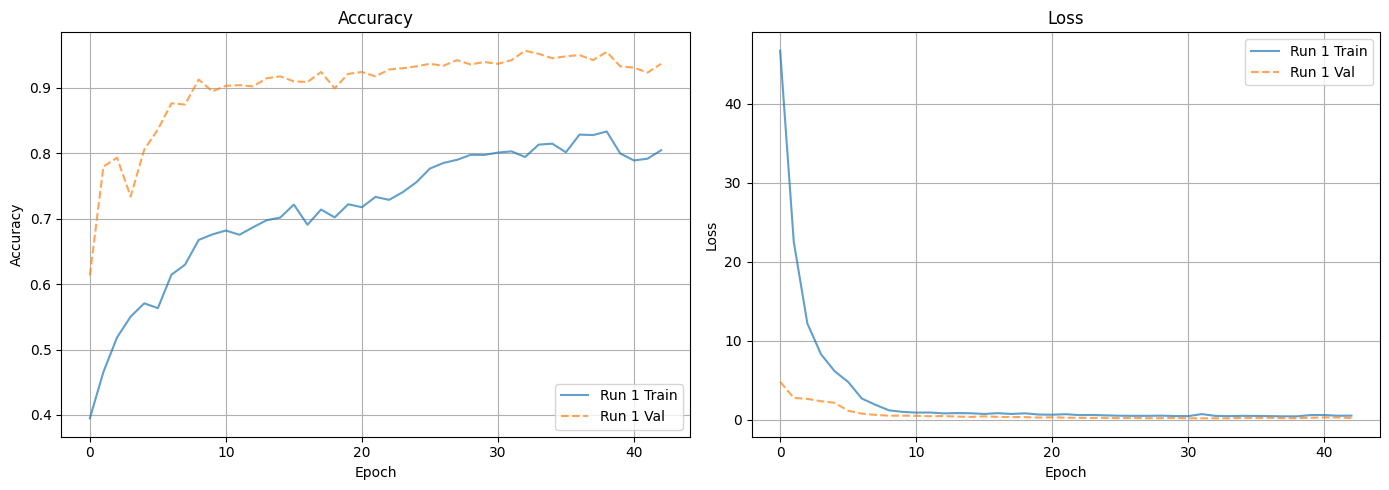

In [33]:
plot_metrics(histories)

## Hyperparameter Tuning

In [ ]:
import optuna
import numpy as np
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

# assume create_sequences() is defined as before,
# and df, train_df, test_df, label_encoder, num_classes are in scope

best_model = None  # to store the best model found during tuning

def build_model(input_shape, 
                n_layers, 
                units, 
                dropout_rate, 
                dense_units, 
                learning_rate):
    m = Sequential()
    m.add(Input(shape=input_shape))
    # stack n_layers LSTMs
    for i in range(n_layers):
        # all but last need to return sequences
        return_seq = (i < n_layers - 1)
        m.add(LSTM(units, return_sequences=return_seq))
        m.add(Dropout(dropout_rate))
    m.add(Dense(dense_units, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return m

def objective(trial):
    # 1) hyperparameter search space
    window_size     = trial.suggest_int('window_size', 10, 100, step=10)
    n_layers        = trial.suggest_int('n_layers',    1,   3)
    units           = trial.suggest_categorical('units', [4,8,16,32,64])
    dropout_rate    = trial.suggest_float('dropout', 0.2, 0.8)
    dense_units     = trial.suggest_categorical('dense_units', [4,8,16,32,64])
    lr              = trial.suggest_float('lr', 1e-6, 1e-3, log=True)
    patience        = 5
    batch_size      = 32
    epochs          = 200  # will stop early

    # 2) build your train/val splits & scale
    X_train, y_train = create_sequences(train_X, train_df['label'], window_size)
    
    # simple 70/30 split for tuning
    N = len(X_train)
    idx = np.random.RandomState(42).permutation(N)
    train_n = int(0.7 * N)
    tr, va = idx[:train_n], idx[train_n:]
    X_tr, y_tr = X_train[tr], y_train[tr]
    X_va, y_va = X_train[va], y_train[va]

    input_shape = X_tr.shape[1:]  # (window_size, n_features)

    # 3) repeat training to average out randomness
    val_accs = []
    for _ in range(10):
        model = build_model(input_shape, n_layers, units, dropout_rate, dense_units, lr)
        es = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True, verbose=0)
        hist = model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[es],
            verbose=2
        )
        val_accs.append(hist.history['val_accuracy'][-1])
        print(f"Trial {trial.number} - Val Accuracy: {val_accs[-1]:.4f}")

    # 4) objective is mean validation accuracy
    if not best_model or np.mean(val_accs) > trial.study.best_value:
        best_model = model
        print(f"New best model found for trial {trial.number} with val accuracy: {np.mean(val_accs):.4f}")
        
    return np.mean(val_accs)

# 5) run the search
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best hyperparameters:", study.best_trial.params)


In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# --- 1) Prepare your train/test sequences with the chosen window_size ---
window_size     = 10
n_layers        = 2
units           = 60
dropout_rate    = 0.2
dense_units     = 16
learning_rate   = 0.0005257423723409036

X_train, y_train = create_sequences(train_X, train_df['label'], window_size)
X_test,  y_test  = create_sequences(test_X,  test_df['label'],  window_size)

N = len(X_train)
idx = np.random.RandomState(38).permutation(N)
train_n = int(0.7 * N)
tr, va = idx[:train_n], idx[train_n:]
X_tr, y_tr = X_train[tr], y_train[tr]
X_va, y_va = X_train[va], y_train[va]


# --- 2) Build the final model ---
def build_model(input_shape, 
                n_layers, 
                units, 
                dropout_rate, 
                dense_units, 
                learning_rate):
    m = Sequential()
    m.add(Input(shape=input_shape))
    # stack n_layers LSTMs
    for i in range(n_layers):
        # all but last need to return sequences
        return_seq = (i < n_layers - 1)
        m.add(LSTM(units, return_sequences=return_seq))
        m.add(Dropout(dropout_rate))
    m.add(Dense(dense_units, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return m

input_shape = X_tr.shape[1:]  # (window_size, n_features)

model = build_model(input_shape, n_layers, units, dropout_rate, dense_units, learning_rate)
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=0)
hist = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=2
)
print("vallidation accuracy: ", hist.history['val_accuracy'][-1])

# --- 4) Final, unbiased evaluation on Clara ---
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy on Clara: {acc*100:.2f}%")

# Confusion matrix + full report
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
y_true = y_test.argmax(axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

In [ ]:
plot_metrics([hist])

# Good run below

In [38]:
histories, cms, reports, accuracies = run_experiment(window_size=45, epochs=50, batch_size=64, repeats=1, units=10, dropout_rate=0.5, dense_units=10, verbose=2, learning_rate=5e-4)


--- Run #1 ---
Epoch 1/50
65/65 - 1s - 19ms/step - accuracy: 0.3324 - loss: 622.3567 - val_accuracy: 0.3748 - val_loss: 157.9761
Epoch 2/50
65/65 - 1s - 9ms/step - accuracy: 0.3611 - loss: 246.0509 - val_accuracy: 0.3931 - val_loss: 166.9234
Epoch 3/50
65/65 - 1s - 8ms/step - accuracy: 0.3213 - loss: 366.1473 - val_accuracy: 0.3150 - val_loss: 230.6041
Epoch 4/50
65/65 - 1s - 8ms/step - accuracy: 0.3290 - loss: 316.0272 - val_accuracy: 0.3767 - val_loss: 184.8281
Epoch 5/50
65/65 - 1s - 8ms/step - accuracy: 0.3288 - loss: 343.3858 - val_accuracy: 0.3613 - val_loss: 206.0692
Epoch 6/50
65/65 - 1s - 8ms/step - accuracy: 0.3451 - loss: 292.1193 - val_accuracy: 0.3873 - val_loss: 154.7652
Epoch 7/50
65/65 - 1s - 8ms/step - accuracy: 0.3702 - loss: 188.7614 - val_accuracy: 0.3526 - val_loss: 100.3848
Epoch 8/50
65/65 - 1s - 8ms/step - accuracy: 0.3958 - loss: 203.3056 - val_accuracy: 0.3738 - val_loss: 451.4606
Epoch 9/50
65/65 - 1s - 8ms/step - accuracy: 0.3779 - loss: 245.0101 - val_accu

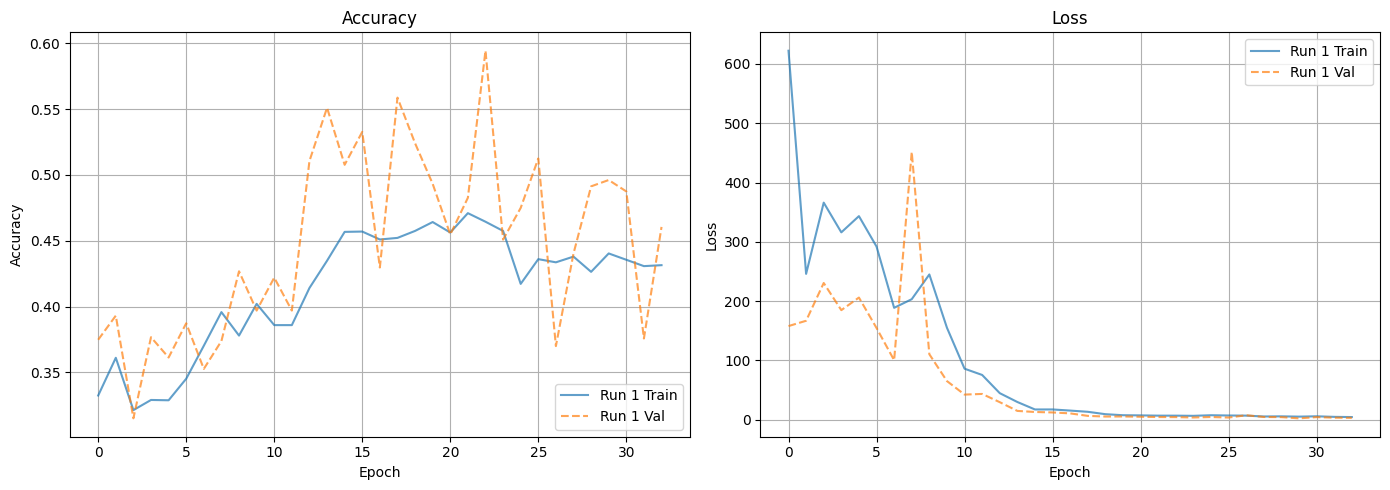

In [40]:
plot_metrics(histories)